In [ ]:
import tensorflow as tf
print(tf.version )


<module 'tensorflow._api.v2.version' from '/usr/local/lib/python3.11/dist-packages/tensorflow/_api/v2/version/__init__.py'>


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, MaxPool2D
from tensorflow.keras.models import Model


In [ ]:
# importing mnist datase
mnist_data = tf.keras.datasets.fashion_mnist
#dividing data into training and test sets
(training_images, training_labels), (test_images, test_labels) = mnist_data.load_data()
training_images, test_images = training_images/255.0, test_images/255.0
print(training_images.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)


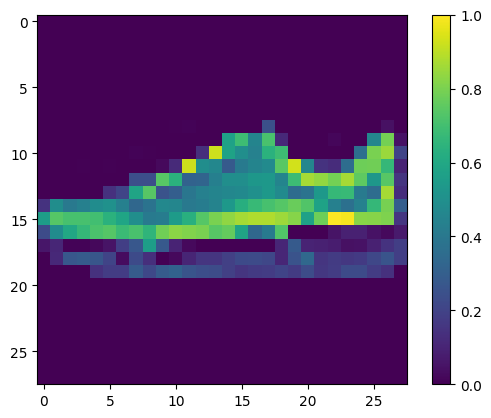

In [ ]:
plt.figure()
plt.imshow(test_images[9])
plt.colorbar()
plt.grid(False)
plt.show()

In [ ]:
training_images = np.expand_dims(training_images, -1)
test_images = np.expand_dims(test_images, -1)
print(training_images.shape)

(60000, 28, 28, 1)


In [ ]:
output_classes = len(set(training_labels))
print("Number of output classes is: ", output_classes)

Number of output classes is:  10


In [ ]:
training_images[0].shape

(28, 28, 1)

In [ ]:
input_layer = Input(shape = training_images[0].shape )
conv1 = Conv2D(32, (3,3), strides = 2, activation= 'relu') (input_layer)
maxpool1 = MaxPool2D(2, 2)(conv1)
conv2 = Conv2D(64, (3,3), strides = 2, activation= 'relu') (maxpool1)
flat1 = Flatten()(conv2)
drop1 = Dropout(0.2)(flat1)
dense1 = Dense(512, activation = 'relu')(drop1)
drop2 = Dropout(0.2)(dense1)
output_layer = Dense(output_classes, activation= 'softmax')(drop2)
model = Model(input_layer, output_layer)


In [ ]:
model.compile(optimizer = 'adam', loss=
'sparse_categorical_crossentropy', metrics =['accuracy'])
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_plot1.png',
show_shapes=True, show_layer_names=True)
#training the CNN model
model_history = model.fit(training_images,
training_labels, epochs=20, validation_data=(test_images,
test_labels), verbose=1)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.6980 - loss: 0.8159 - val_accuracy: 0.8366 - val_loss: 0.4482
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.8347 - loss: 0.4451 - val_accuracy: 0.8494 - val_loss: 0.4082
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8552 - loss: 0.3912 - val_accuracy: 0.8666 - val_loss: 0.3709
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8666 - loss: 0.3544 - val_accuracy: 0.8718 - val_loss: 0.3543
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8728 - loss: 0.3402 - val_accuracy: 0.8753 - val_loss: 0.3394
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8812 - loss: 0.3163 - val_accuracy: 0.8729 - val_loss: 0.3502
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8867 - loss: 0.3016 - val_accuracy: 0.8772 - val_loss: 0.3343
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8913 - loss: 0

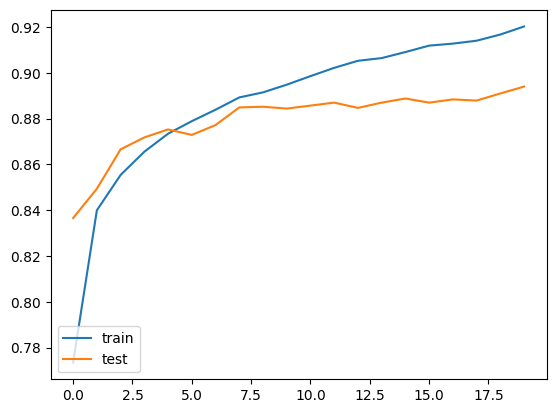

In [ ]:
import matplotlib.pyplot as plt
plt.plot(model_history.history['accuracy'], label='accuracy')
plt.plot(model_history.history['val_accuracy'], label='val_accuracy')
plt.legend(['train','test'], loc='lower left')

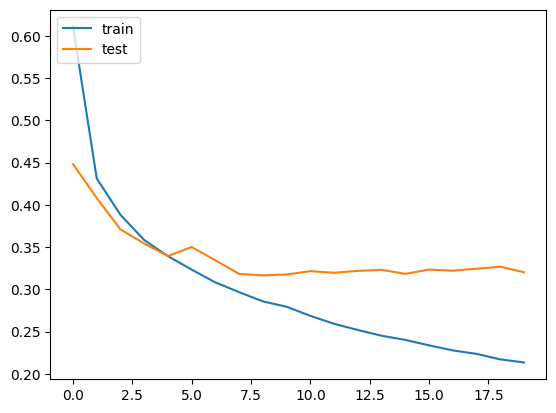

In [ ]:
plt.plot(model_history.history['loss'], label = 'loss')
plt.plot(model_history.history['val_loss'], label = 'val_loss')
plt.legend(['train','test'], loc='upper left')


In [ ]:
output = model.predict(test_images)
prediction = np.argmax(output[9])
print(prediction)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
7


In [ ]:
cifar_dataset = tf.keras.datasets.cifar10